# **T2A** Ressonância em tubos

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import sys
sys.path.append("../..")
import base as b
import importlib
importlib.reload(b)
from tabulate import tabulate

## Tubos com 1 extremo aberto

### f vs n

Beta: [1.307375 0.595625]
Beta Std Error: [0.00146113 0.01286293]
Beta Covariance: [[ 0.00294118 -0.02205888]
 [-0.02205888  0.22794147]]
Residual Variance: 0.0007258660597076568
Inverse Condition #: 0.057006084209910775
Reason(s) for Halting:
  Sum of squares convergence
Beta: [0.76508088 0.44556617]
Beta Std Error: [0.00076171 0.00780523]
Beta Covariance: [[ 0.00245097 -0.02205878]
 [-0.02205878  0.25735292]]
Residual Variance: 0.0002367240182221747
Inverse Condition #: 0.04473761657229199
Reason(s) for Halting:
  Sum of squares convergence
Beta: [0.94733609 0.41975714]
Beta Std Error: [0.00122736 0.01363974]
Beta Covariance: [[ 0.00150376 -0.01428569]
 [-0.01428569  0.18571417]]
Residual Variance: 0.0010017685374033624
Inverse Condition #: 0.045150347807804705
Reason(s) for Halting:
  Sum of squares convergence
Beta: [2.06098179 1.08598202]
Beta Std Error: [0.01656011 0.0884068 ]
Beta Covariance: [[ 0.01212119 -0.05454536]
 [-0.05454536  0.34545408]]
Residual Variance: 0.02262460814

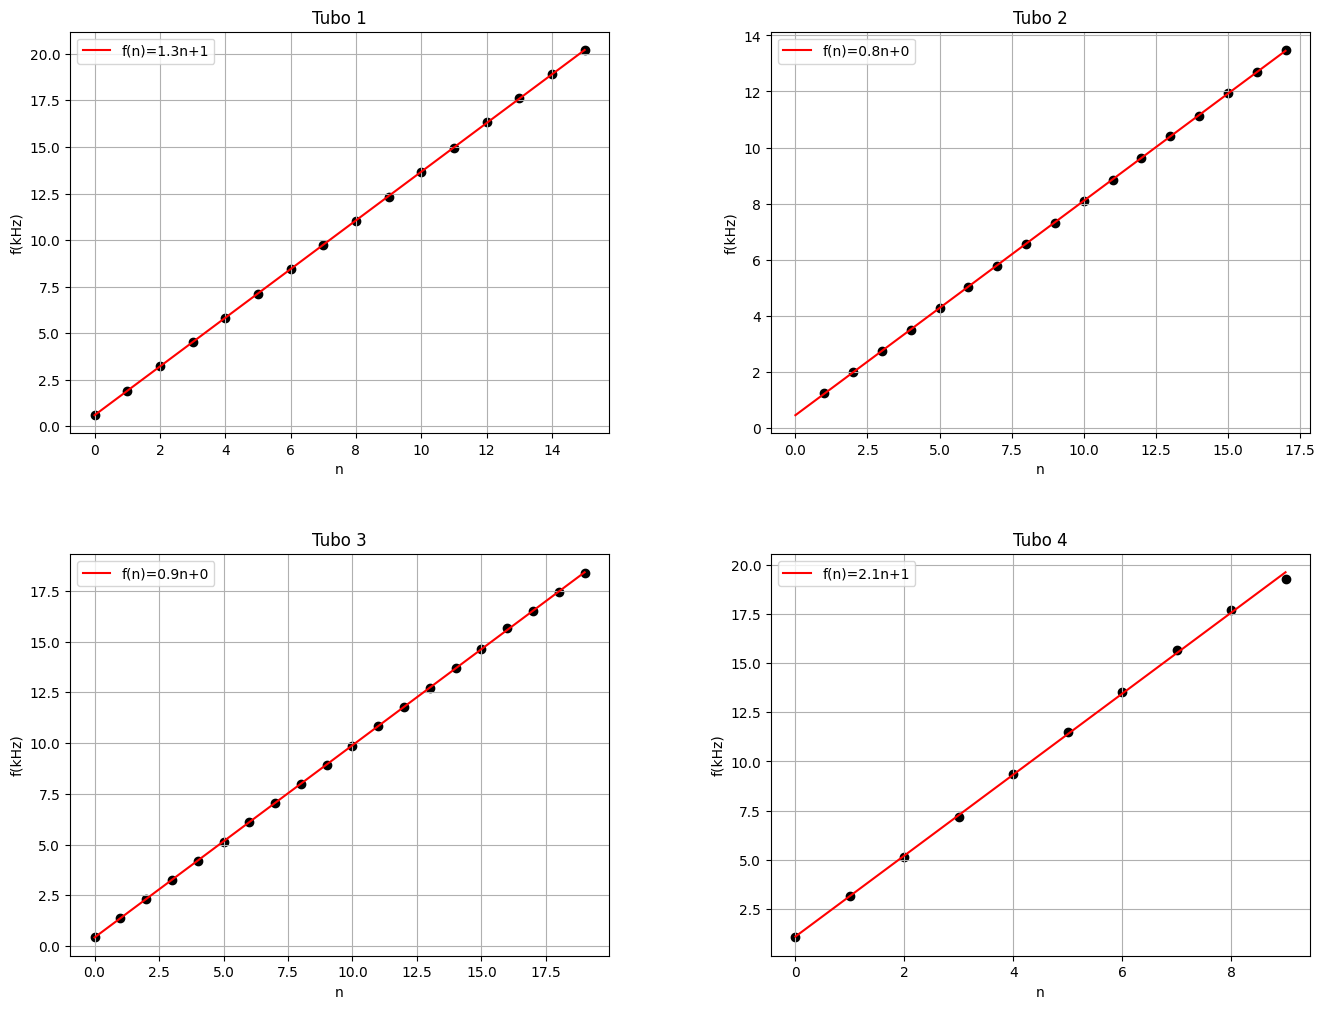

In [9]:
data = b.getData("T2A_extaberto.txt")

params = data[0::3]
freqs  = data[1::3]
ns     = data[2::3]

ns[0] -= 1
ns[2] -= 1
ns[3] -= 1

fig, axs = plt.subplots(2,2,figsize=(16,12))
fig.subplots_adjust(hspace=0.3, wspace=0.3)
axs_iter = iter(axs.flat)

regress = []
incRegress = []

tube = 0
for i in range(len(freqs)):
    f = freqs[i]/1000
    n = ns[i]

    f = f[~np.isnan(f)]
    n = n[~np.isnan(n)]

    adjust = b.getAdjust(b.lin,n,f,.0001,1)
    regress.append(adjust.beta)
    incRegress.append(adjust.sd_beta)
    adjust.pprint()

    nn = np.linspace(0,n[-1],100)
    ff = b.lin(adjust.beta, nn)

    ax =next(axs_iter)
    ax.set_title(f"Tubo {tube+1}")
    ax.set_xlabel("n")
    ax.set_ylabel("f(kHz)")
    ax.scatter(n,f,c="black")
    ax.plot(nn,ff,c="red",label='f(n)={0:.1f}n+{1:.0f}'.format(adjust.beta[0],adjust.beta[1]))
    ax.legend()
    ax.grid()
    tube += 1

plt.show()


  


#### Dá pra ver que a incerteza é maior na ordenada na origem ent refere-se q o declive é mlhr método, a razão acho q é pq a ordenada na origem é mais afetada plas incertezas do y enquanto o declive é afetado plas incertezas no y e no x mas n há incerteza em x ent isso suaviza a incerteza total, mas pode-se meter na mesma o outro

Velocidade de referência = 347.22 com incerteza 0.19 m/s

1º Tubo:
v (dec)
  v = 346.91 m/s
  u(v) = 0.38 m/s
  Erro rel. = 0.11%
  Desvio rel. valor ref. = 0.09%

v (ord. org)
  v = 316.09 m/s
  u(v) = 6.83 m/s
  Erro rel. = 2.16%
  Desvio rel. valor ref. = 8.97%


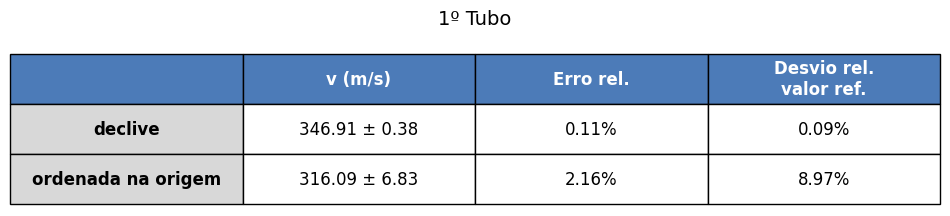


2º Tubo:
v (dec)
  v = 341.58 m/s
  u(v) = 1.57 m/s
  Erro rel. = 0.46%
  Desvio rel. valor ref. = 1.62%

v (ord. org)
  v = 397.86 m/s
  u(v) = 7.19 m/s
  Erro rel. = 1.81%
  Desvio rel. valor ref. = 14.58%


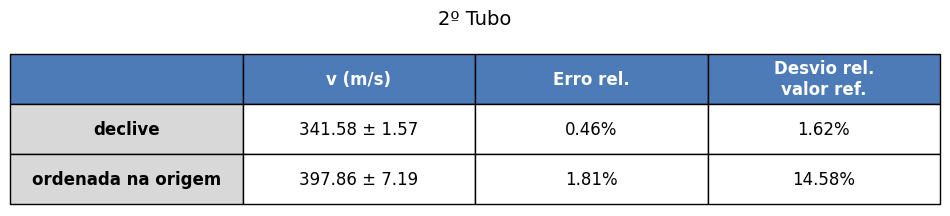


3º Tubo:
v (dec)
  v = 347.19 m/s
  u(v) = 1.95 m/s
  Erro rel. = 0.56%
  Desvio rel. valor ref. = 0.01%

v (ord. org)
  v = 307.67 m/s
  u(v) = 10.14 m/s
  Erro rel. = 3.29%
  Desvio rel. valor ref. = 11.39%


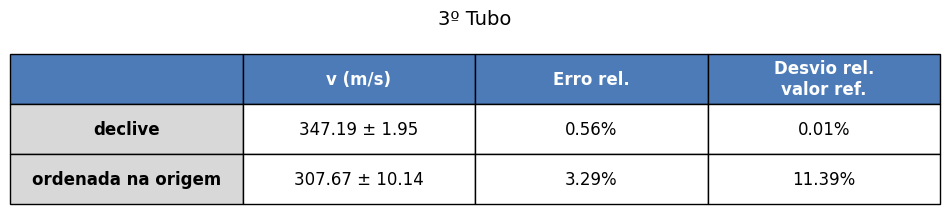


4º Tubo:
v (dec)
  v = 345.53 m/s
  u(v) = 2.68 m/s
  Erro rel. = 0.78%
  Desvio rel. valor ref. = 0.49%

v (ord. org)
  v = 364.14 m/s
  u(v) = 29.64 m/s
  Erro rel. = 8.14%
  Desvio rel. valor ref. = 4.87%


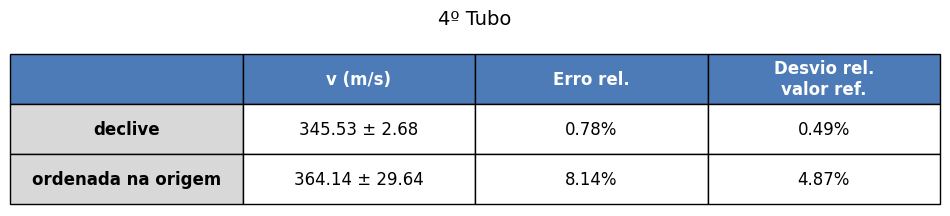

In [10]:
T = 24.5
uT=0.01
pvH20 =11.885
upvH20=2.4 #incerteza da média q usamos
vRef = 331.4+0.607*T+0.08*pvH20
uvRef= np.sqrt((0.607*uT)**2+(0.08*upvH20)**2)
print(f"Velocidade de referência = {vRef:.2f} com incerteza {uvRef:.2f} m/s\n")

for i in range(0,len(regress)):
    l = params[i,1]
    D = params[i,0]
    ul = params[i,3]
    uD = params[i,2]
    dec = regress[i][0]
    udec = incRegress[i][0]
    ord = regress[i][1]
    uord = incRegress[i][1]
                     
    vDec = dec*2*(l+0.305*D)/100 *1000
    desvioDec = abs(vDec-vRef)/vRef *100
    incDec = np.sqrt((2*(l+.0305*D)*udec)**2+(2*dec*ul)**2+(0.305*2*dec*uD)**2)/100 *1000

    vOrd = ord*4*(l+0.305*D)/100 *1000
    desvioOrd = abs(vOrd-vRef)/vRef *100
    incOrd = np.sqrt((4*(l+.305*D)*uord)**2+(4*ord*ul)**2+(4*.305*ord*uD)**2)/100 *1000

    print(f"{i+1}º Tubo:")


    print("v (dec)")
    print(f"  v = {vDec:.2f} m/s")
    print(f"  u(v) = {incDec:.2f} m/s")
    print(f"  Erro rel. = {incDec/vDec*100:.2f}%")
    print(f"  Desvio rel. valor ref. = {desvioDec:.2f}%")

    print()

    print("v (ord. org)")
    print(f"  v = {vOrd:.2f} m/s")
    print(f"  u(v) = {incOrd:.2f} m/s")
    print(f"  Erro rel. = {incOrd/vOrd*100:.2f}%")
    print(f"  Desvio rel. valor ref. = {desvioOrd:.2f}%")

    # Dados da tabela
    data = [
        ["declive", f"{vDec:.2f} ± {incDec:.2f}", f"{incDec/vDec*100:.2f}%", f"{desvioDec:.2f}%"],
        ["ordenada na origem", f"{vOrd:.2f} ± {incOrd:.2f}", f"{incOrd/vOrd*100:.2f}%", f"{desvioOrd:.2f}%"]
    ]

    # Cabeçalhos
    columns = ["", "v (m/s)", "Erro rel.", "Desvio rel.\nvalor ref."]

    # Criar figura
    fig, ax = plt.subplots(figsize=(8, 2))  # ajusta o tamanho
    ax.axis('tight')
    ax.axis('off')  # remove eixos

    # Criar tabela
    table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')

    # Ajustar estilo
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.5, 3)  # escala horizontal e vertical

    # Colorir os headers (linha 0)
    for j in range(len(columns)):
        cell = table[(0, j)]
        cell.set_facecolor("#4C7BB8")   # verde
        cell.set_text_props(color="white", weight='bold')

    # Colorir a primeira coluna (coluna 0, excluindo o header)
    for i_row in range(1, len(data)+1):
        cell = table[(i_row, 0)]
        cell.set_facecolor("#d8d8d8")   # cinza claro
        cell.set_text_props(weight='bold')

    # Título
    plt.title(f"{i+1}º Tubo", fontsize=14, pad=20)

    plt.show()


    print()

### l vs 1/f

AJUSTES PRÉVIOS


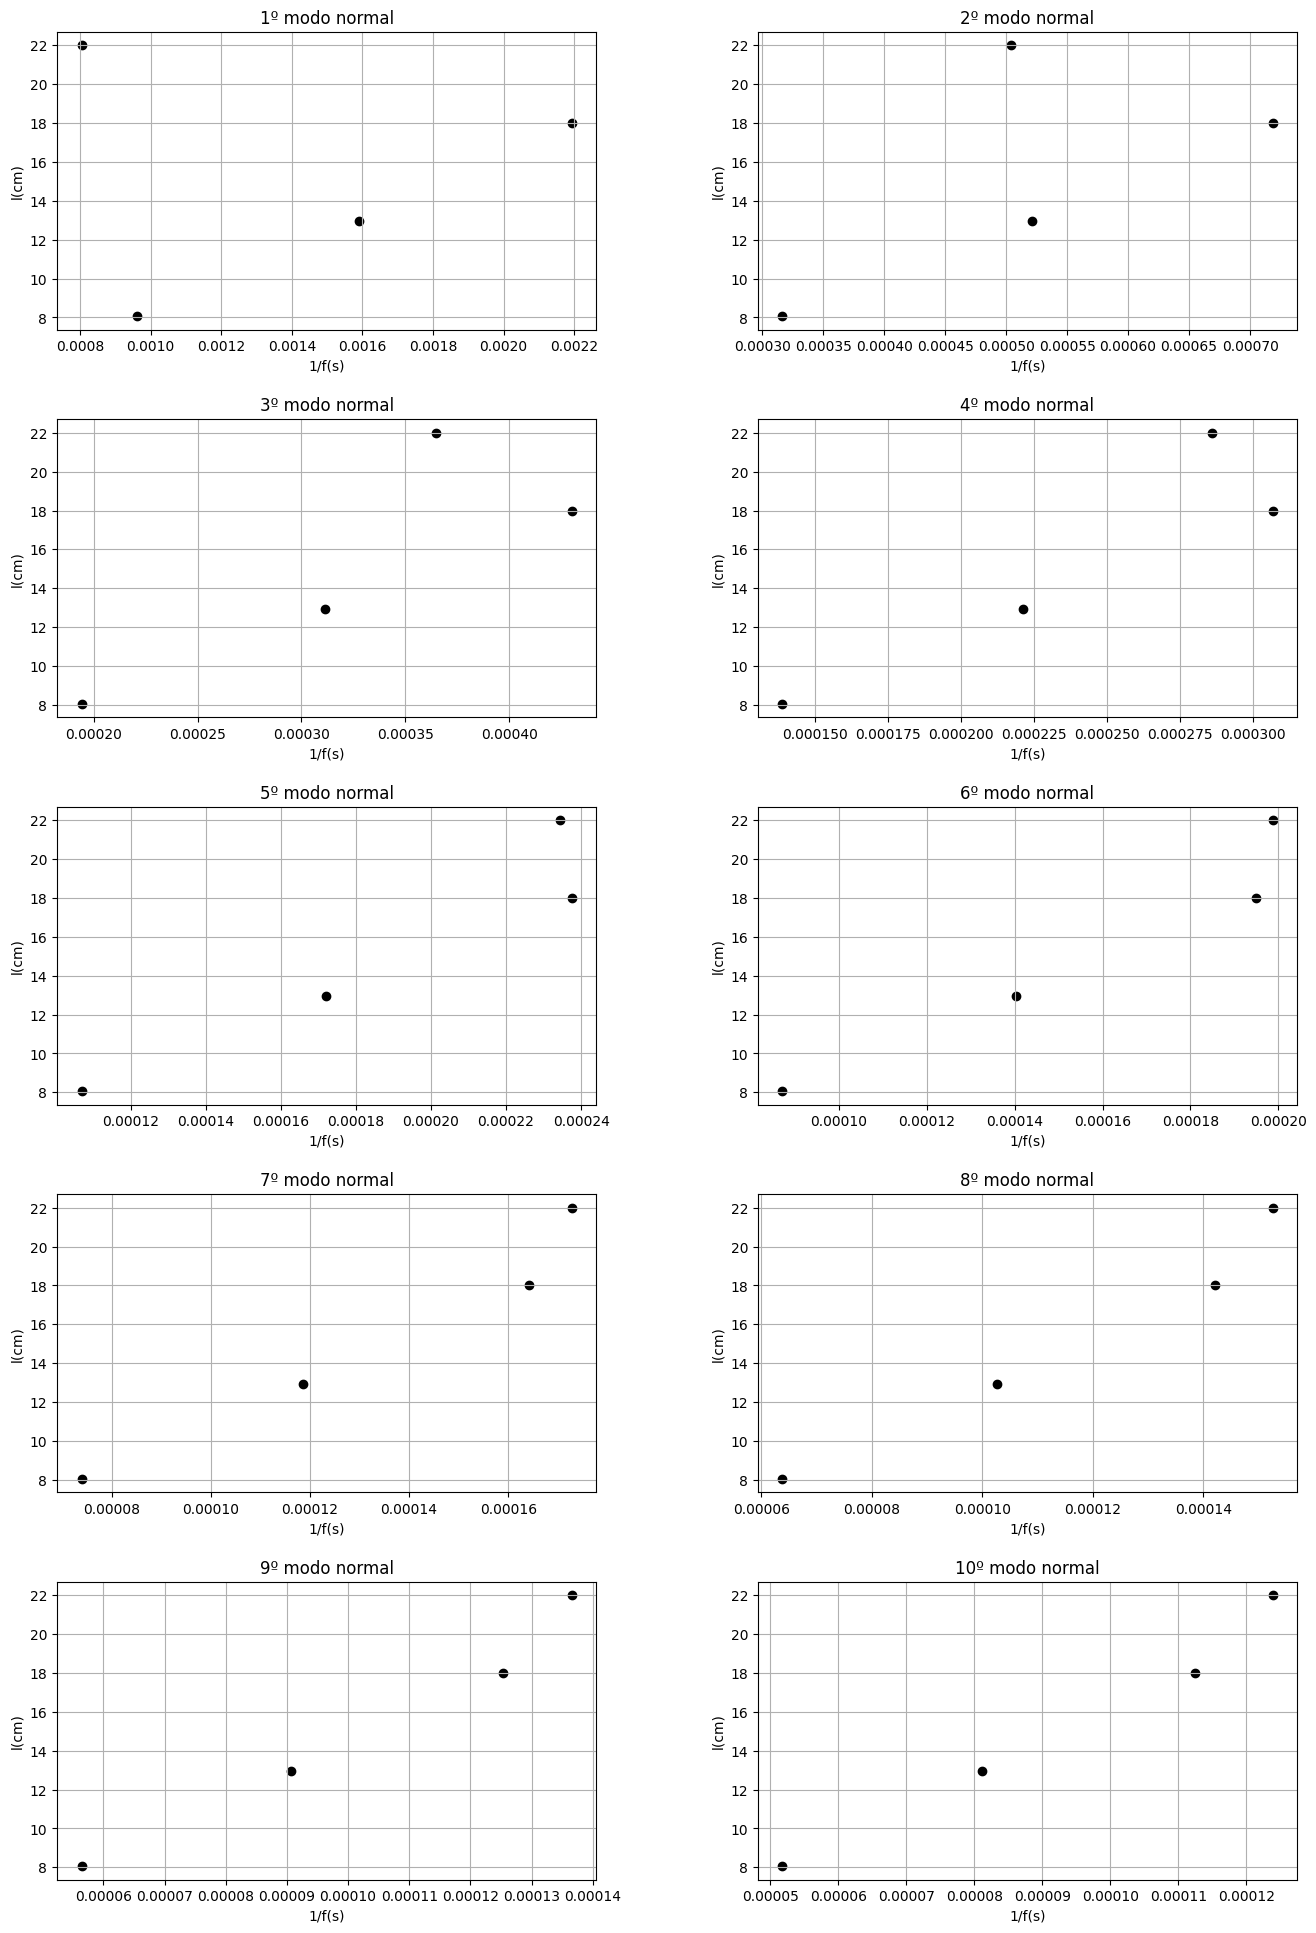

In [11]:
print('AJUSTES PRÉVIOS')
ls = params[:,1]
ls = ls[~np.isnan(ls)]

fig, axs = plt.subplots(5,2,figsize=(16,24))
fig.subplots_adjust(hspace=0.3, wspace=0.3)
axs_iter = iter(axs.flat)

for i in range(10):
    
    ax =next(axs_iter)

    f = freqs[:,i]
    f = f[~np.isnan(f)]
    f = 1/f
    ax.scatter(f,ls, c ="black")
    ax.set_title(f"{i+1}º modo normal")
    ax.set_xlabel('1/f(s)')
    ax.set_ylabel('l(cm)')
    ax.grid()


Claramente o ponto do tubo de 22 cm está sempre deslocado o que sugere que o primeiro ponto registado representa, na realidade o modo normal 2. Então vai usar-se uma frequência tirada da regressão

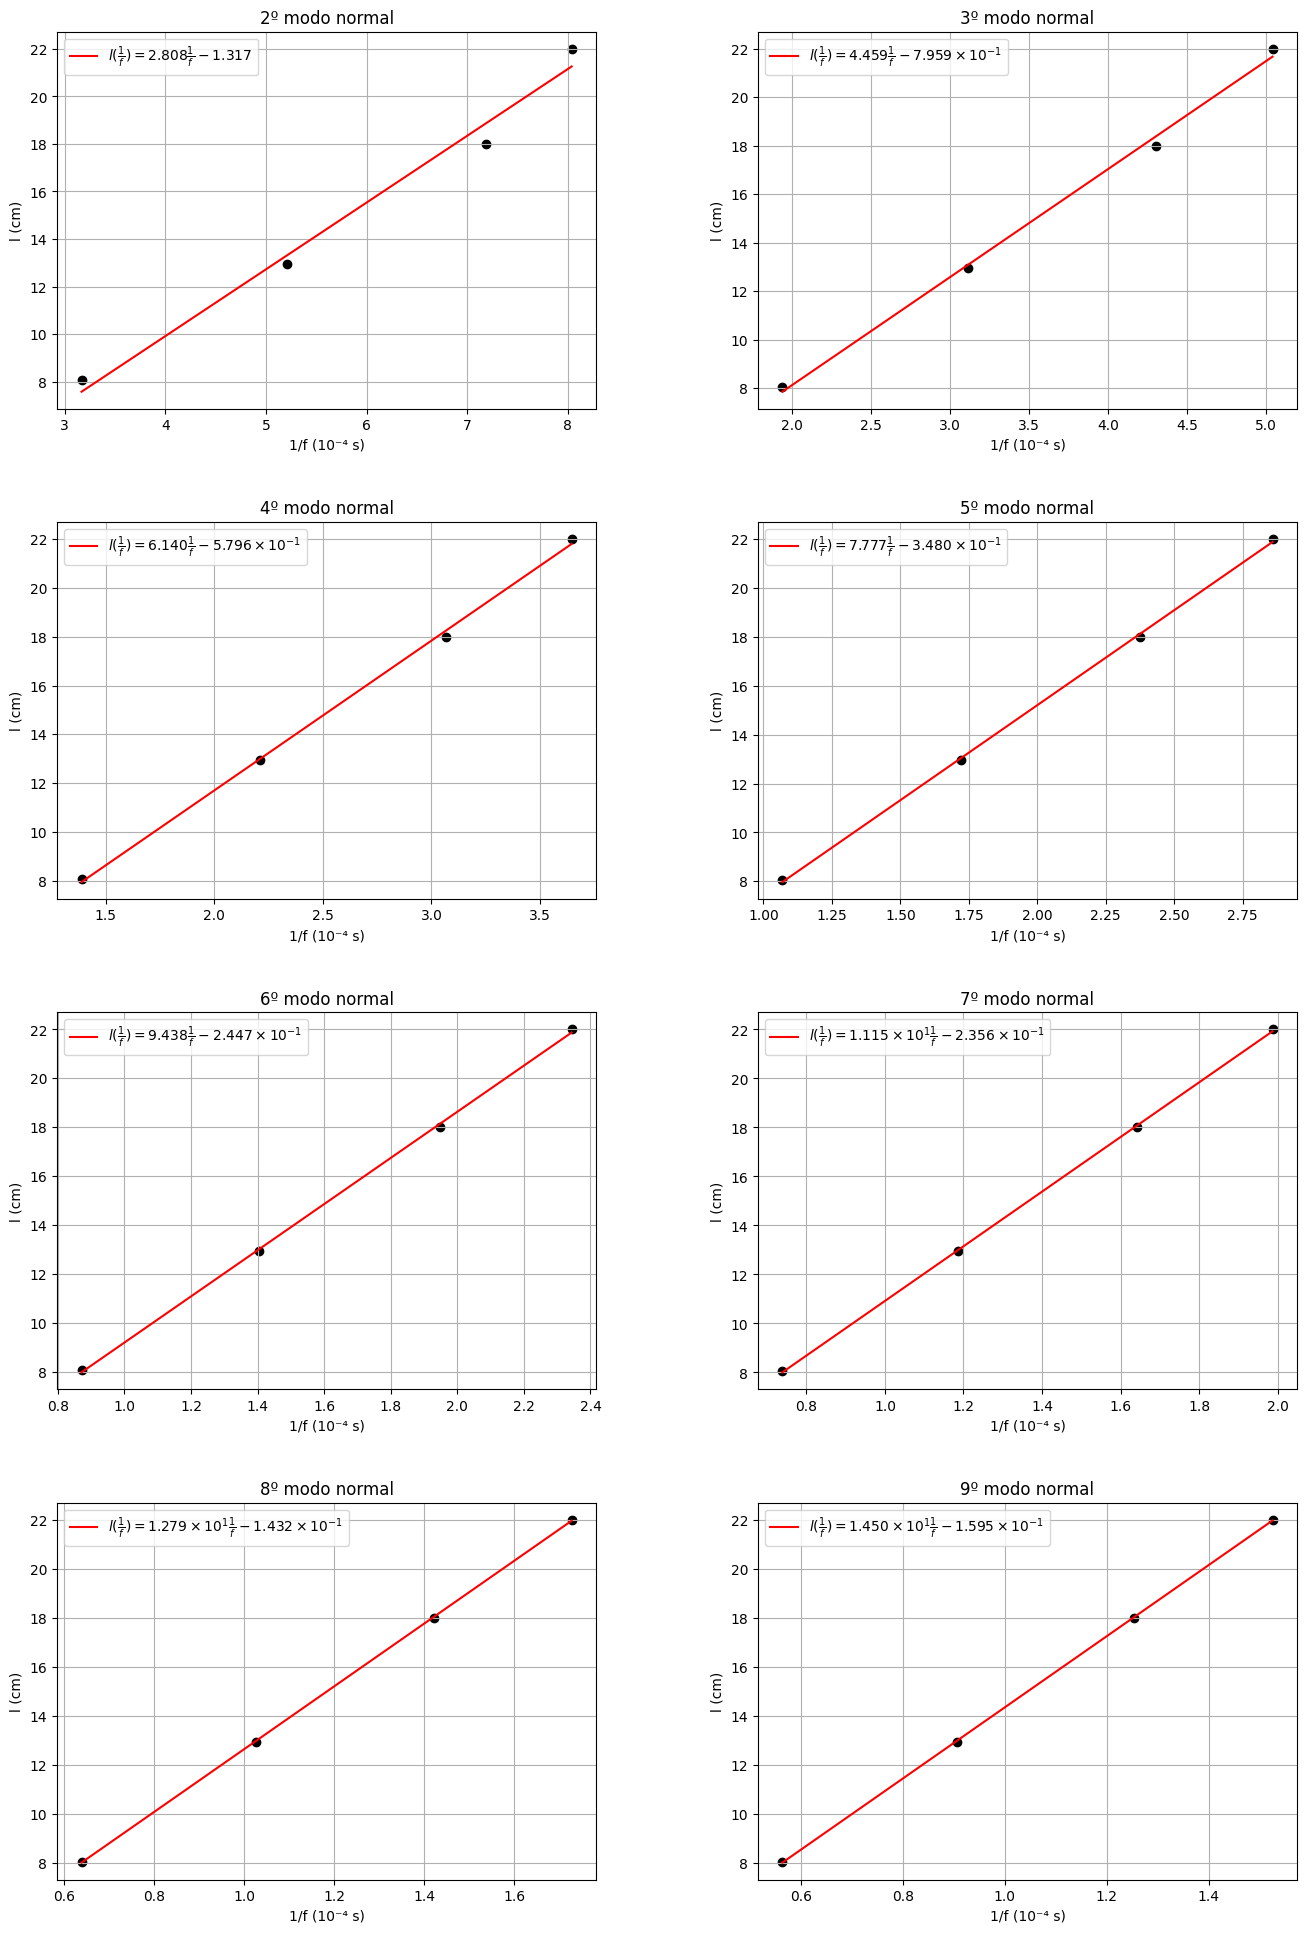

In [12]:
uls = params[:,3]


fig, axs = plt.subplots(4,2,figsize=(16,24))
fig.subplots_adjust(hspace=0.3, wspace=0.3)
axs_iter = iter(axs.flat)

freq = freqs[1]

freq[1:] = freq[:-1]
freq[0] = np.nan
freqs[1] = freq


for i in range(1,9):

    ax = next(axs_iter)

    f = freqs[:,i]
    f = f[~np.isnan(f)]
    f = 1/f *10000

    ax.scatter(f,ls, c ="black")
    adjust = b.getAdjust(b.lin,f,ls,1,uls)
    x = np.linspace(min(f), max(f))
    y = b.lin(adjust.beta, x)
    ax.set_title(f"{i+1}º modo normal")
    ax.plot(x,y,c="red", label=b.getPolynomialLabel(adjust.beta,r"\frac{1}{f}", "l"))
    ax.set_xlabel("1/f (10⁻⁴ s)")
    ax.set_ylabel("l (cm)")
    ax.legend()
    ax.grid()

Teve de usar-se 10⁻⁴ de maneira a reduzir o erro na regressão, caso contrário, os declives estariam todos mal.

## Extremos fechados

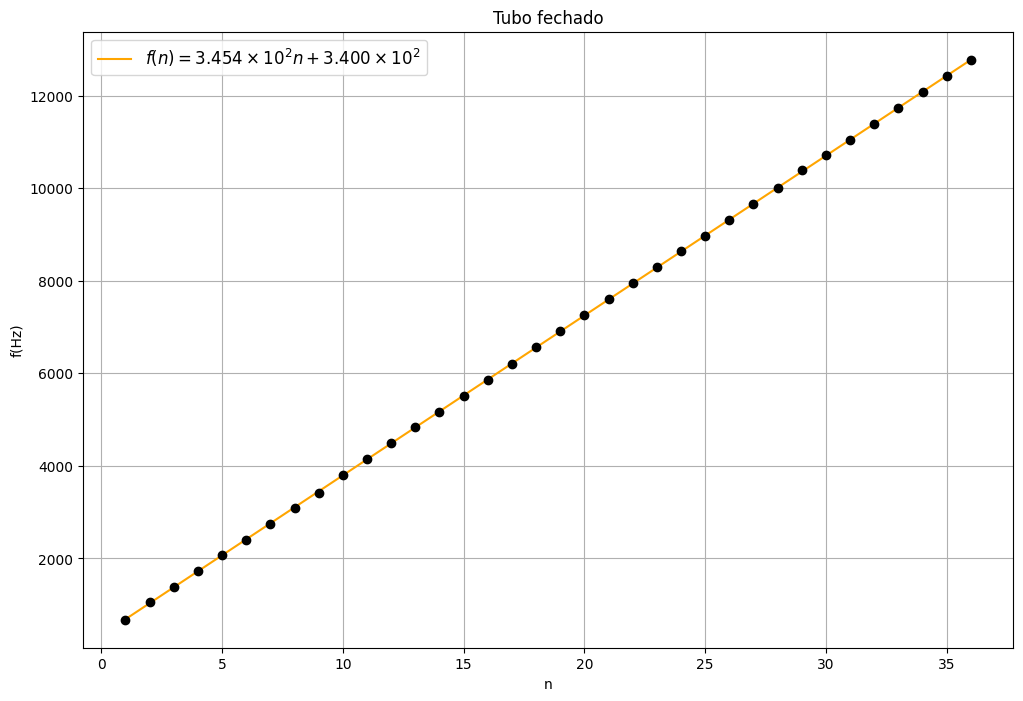

Beta: [345.39305661 339.95067246]
Beta Std Error: [0.22639183 4.80338283]
Beta Covariance: [[ 0.00025771 -0.00476759]
 [-0.00476759  0.11601128]]
Residual Variance: 198.88140576204347
Inverse Condition #: 0.022645821026137852
Reason(s) for Halting:
  Sum of squares convergence


In [13]:
l = 50.5
ul = .1

data = b.getData("T2A_extfechado.txt")

fs = data[0]
ns = data[1]

adjust = b.plotLinReg(ns,fs,0.0001,1,"Tubo fechado","n", "f(Hz)")
adjust.pprint()

v (dec)
  v = 348.85 m/s
  u(v) = 0.73 m/s
  Erro rel. = 0.21%
  Desvio rel. valor ref. = 1.12%

v (ord. org)
  v = 343.35 m/s
  u(v) = 0.71 m/s
  Erro rel. = 0.21%
  Desvio rel. valor ref. = 4.87%



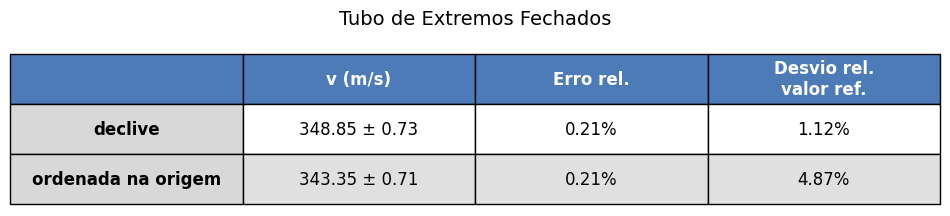

In [17]:
dec = adjust.beta[0]
udec = adjust.sd_beta[0]
ord = adjust.beta[1]
uord = adjust.sd_beta[1]

vDec = dec*2*l/100
desvioDec = abs(vDec-vRef)/vRef *100
incDec = np.sqrt((2*l*udec)**2+(2*dec*ul)**2)/100

vOrd = ord*2*l/100
desvioDec = abs(vOrd-vRef)/vRef *100
incOrd = np.sqrt(np.sqrt(2*l*uord)**2+(2*ord*ul)**2)/100

print("v (dec)")
print(f"  v = {vDec:.2f} m/s")
print(f"  u(v) = {incDec:.2f} m/s")
print(f"  Erro rel. = {incDec/vDec*100:.2f}%")
print(f"  Desvio rel. valor ref. = {desvioDec:.2f}%")

print()

print("v (ord. org)")
print(f"  v = {vOrd:.2f} m/s")
print(f"  u(v) = {incOrd:.2f} m/s")
print(f"  Erro rel. = {incOrd/vOrd*100:.2f}%")
print(f"  Desvio rel. valor ref. = {desvioOrd:.2f}%")

print()

# Dados da tabela
data = [
    ["declive", f"{vDec:.2f} ± {incDec:.2f}", f"{incDec/vDec*100:.2f}%", f"{desvioDec:.2f}%"],
    ["ordenada na origem", f"{vOrd:.2f} ± {incOrd:.2f}", f"{incOrd/vOrd*100:.2f}%", f"{desvioOrd:.2f}%"]
]

# Cabeçalhos
columns = ["", "v (m/s)", "Erro rel.", "Desvio rel.\nvalor ref."]

b.getTable(columns,data, "Tubo de Extremos Fechados", True,(8,2))